In [13]:
# ============================================================
# FILTER-BANK + PCA + LDA
# Stroke Rehab EEG Classification
# Preprocessing from Filter-Bank TS-LDA notebook
# ============================================================

import os
import sys
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import mne

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)



In [14]:
# ============================================================
# SETTINGS
# ============================================================

DATA_DIR = r"E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set"

SUBJECTS = ["P1", "P2", "P3"]
STAGES   = ["pre", "post"]

CH_NAMES = [
    "FC5", "FC1", "FCz", "FC2", "FC6",
    "C5",  "C3",  "C1",  "Cz",  "C2",  "C4",  "C6",
    "CP5", "CP1", "CP2", "CP6"
]

EVENT_ID = {"left_hand": 1, "right_hand": 2}

TMIN     = 2.0
TMAX     = 8.0
BASELINE = (2.0, 2.5)

FILTER_BANKS = [
    (8,  12),   # mu / alpha
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 30)    # beta
]

N_SPLITS     = 5
RANDOM_STATE = 42
N_COMPONENTS = 0.98   # keep 95% variance across all filter-bank features



In [15]:
# ============================================================
# DATA LOADING  (same as Filter-Bank notebook)
# ============================================================

def load_mat_file(filepath, scale_to_volts=True):
    mat  = sio.loadmat(filepath)
    fs   = int(np.squeeze(mat["fs"]))
    y    = mat["y"]
    trig = np.squeeze(mat["trig"])
    if scale_to_volts:
        y = y * 1e-6
    return y, trig, fs


def extract_events_from_trigger(trig):
    trig   = trig.flatten()
    onsets = np.where(np.diff((trig != 0).astype(int)) == 1)[0] + 1
    labels = trig[onsets]
    codes  = np.where(labels == 1, 1, 2)
    events = np.column_stack([onsets, np.zeros(len(onsets), dtype=int), codes])
    return events


def make_raw(filepath):
    y, trig, fs = load_mat_file(filepath)

    info = mne.create_info(
        ch_names=CH_NAMES,
        sfreq=fs,
        ch_types=["eeg"] * len(CH_NAMES)
    )
    montage = mne.channels.make_standard_montage("standard_1020")
    info.set_montage(montage, on_missing="ignore")

    raw = mne.io.RawArray(y.T, info, verbose=False)
    raw.set_eeg_reference("average", projection=False, verbose=False)

    events = extract_events_from_trigger(trig)
    return raw, events, fs


def make_epochs_for_band(filepath, l_freq, h_freq):
    raw, events, fs = make_raw(filepath)

    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design="firwin", verbose=False)

    epochs = mne.Epochs(
        raw, events,
        event_id=EVENT_ID,
        tmin=TMIN, tmax=TMAX,
        baseline=BASELINE,
        preload=True,
        picks="eeg",
        verbose=False
    )

    X = epochs.get_data()
    y = epochs.events[:, 2]
    return epochs, X, y, fs


def make_filterbank_epochs(filepath):
    """
    Returns X_fb : trials x bands x channels x samples
    """
    X_bands    = []
    y_ref      = None
    epochs_ref = None
    fs_ref     = None

    for l_freq, h_freq in FILTER_BANKS:
        epochs, X, y, fs = make_epochs_for_band(filepath, l_freq, h_freq)
        X_bands.append(X)

        if y_ref is None:
            y_ref      = y
            epochs_ref = epochs
            fs_ref     = fs
        else:
            assert np.array_equal(y_ref, y), "Labels mismatch across filter banks"

    X_fb = np.stack(X_bands, axis=1)   # trials x bands x channels x time
    return epochs_ref, X_fb, y_ref, fs_ref



In [16]:
# ============================================================
# Z-SCORE PER BAND  (fit on train, apply to both)
# ============================================================

class FilterBankZScore(BaseEstimator, TransformerMixin):
    """Z-score normalisation across trials and time, per band per channel."""
    def fit(self, X, y=None):
        # X : trials x bands x channels x time
        self.mean_ = X.mean(axis=(0, 3), keepdims=True)
        self.std_  = X.std(axis=(0, 3), keepdims=True)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_



In [17]:
# ============================================================
# FILTER-BANK FEATURE EXTRACTOR: concatenate flattened bands
# ============================================================

class FilterBankFlatten(BaseEstimator, TransformerMixin):
    """
    Flatten each band's epoch data (channels x time) and concatenate
    across bands to produce a single feature vector per trial.

    X in : trials x bands x channels x time
    X out: trials x (bands * channels * time)
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        n_trials = X.shape[0]
        return X.reshape(n_trials, -1)



In [18]:
# ============================================================
# PIPELINE
# ============================================================

def build_fb_pca_lda_pipeline():
    return Pipeline([
        ("zscore",  FilterBankZScore()),
        ("flatten", FilterBankFlatten()),
        ("pca",     PCA(n_components=N_COMPONENTS)),
        ("lda",     LDA(solver="lsqr", shrinkage="auto"))
    ])



In [19]:
# ============================================================
# VISUALIZATION (same as Filter-Bank notebook)
# ============================================================

def plot_some_eeg_trials(epochs, y, subject, stage, n_trials=3):
    data  = epochs.get_data()
    times = epochs.times

    print(f"\nEpoch data shape : {data.shape}")
    print(f"Time range       : {times[0]:.2f}s  to  {times[-1]:.2f}s")

    for idx in range(min(n_trials, len(data))):
        label = "left_hand" if y[idx] == 1 else "right_hand"
        plt.figure(figsize=(14, 8))
        offset = 0
        for ch in range(data.shape[1]):
            sig = data[idx, ch, :] * 1e6
            plt.plot(times, sig + offset, linewidth=0.8)
            offset += np.nanmax(np.abs(sig)) * 2.2 + 1e-6
        plt.title(f"EEG Waveforms | {subject} {stage} | Trial {idx} | Label: {label}")
        plt.xlabel("Time (s)")
        plt.ylabel("Channels (offset)")
        plt.grid(alpha=0.3)
        plt.show()


def plot_electrode_intensity_bar(epochs, subject, stage):
    data      = epochs.get_data()
    intensity = np.mean(data ** 2, axis=(0, 2)) * 1e12

    plt.figure(figsize=(12, 5))
    plt.bar(epochs.ch_names, intensity)
    plt.xticks(rotation=45)
    plt.ylabel("Mean Power (µV²)")
    plt.title(f"Electrode Intensities | {subject} {stage}")
    plt.grid(axis="y", alpha=0.3)
    for i, v in enumerate(intensity):
        plt.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_scalp_intensity(epochs, subject, stage):
    data      = epochs.get_data()
    intensity = np.mean(data ** 2, axis=(0, 2)) * 1e12

    fig, ax = plt.subplots(figsize=(6, 5))
    im, _   = mne.viz.plot_topomap(
        intensity, epochs.info,
        axes=ax, show=False,
        contours=6,
        names=epochs.ch_names,
        sensors=True
    )
    ax.set_title(f"Scalp Intensity | {subject} {stage}")
    plt.colorbar(im, ax=ax, label="Mean Power (µV²)")
    plt.show()


def visualize_one_dataset(subject="P1", stage="pre"):
    filepath = os.path.join(DATA_DIR, f"{subject}_{stage}_training.mat")
    # use middle band (mu/alpha) for visualisation
    epochs, X, y, fs = make_epochs_for_band(filepath, 8, 30)

    print("\n" + "=" * 70)
    print("VISUALIZATION DATA")
    print("=" * 70)
    print(f"File          : {filepath}")
    print(f"Sampling rate : {fs} Hz")
    print(f"Epoch shape   : {X.shape}")
    print(f"Labels        : {dict(zip(*np.unique(y, return_counts=True)))}")

    plot_some_eeg_trials(epochs, y, subject, stage, n_trials=3)
    plot_electrode_intensity_bar(epochs, subject, stage)
    plot_scalp_intensity(epochs, subject, stage)



In [20]:
# ============================================================
# RUN ONE TRAIN / TEST PAIR
# ============================================================

def run_one_pair(subject, stage):
    train_file = os.path.join(DATA_DIR, f"{subject}_{stage}_training.mat")
    test_file  = os.path.join(DATA_DIR, f"{subject}_{stage}_test.mat")

    print("\n" + "=" * 80)
    print(f"FB + PCA + LDA | Subject: {subject} | Stage: {stage.upper()}")
    print("=" * 80)

    train_epochs, X_train, y_train, fs = make_filterbank_epochs(train_file)
    _,            X_test,  y_test,  _  = make_filterbank_epochs(test_file)

    print(f"Sampling rate : {fs} Hz")
    print(f"Filter banks  : {FILTER_BANKS}")
    print(f"X_train shape : {X_train.shape}  (trials x bands x channels x time)")
    print(f"X_test  shape : {X_test.shape}")
    print(f"Train labels  : {dict(zip(*np.unique(y_train, return_counts=True)))}")
    print(f"Test  labels  : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

    model = build_fb_pca_lda_pipeline()

    # Cross-validation
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

    # Train final model
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)
    cv_acc    = cv_scores.mean()
    cv_std    = cv_scores.std()

    print("\nAccuracies")
    print(f"Training Accuracy : {train_acc * 100:.2f}%")
    print(f"Test Accuracy     : {test_acc  * 100:.2f}%")
    print(f"CV Accuracy       : {cv_acc    * 100:.2f}% ± {cv_std * 100:.2f}%")

    print("\nClassification Report - TRAIN")
    print(classification_report(y_train, y_train_pred, target_names=["left_hand", "right_hand"]))

    print("\nClassification Report - TEST")
    print(classification_report(y_test, y_test_pred, target_names=["left_hand", "right_hand"]))

    cm   = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["left_hand", "right_hand"])
    disp.plot(cmap="Blues")
    plt.title(f"FB+PCA+LDA Confusion Matrix | {subject} {stage}")
    plt.show()

    return {
        "method":    "FB-PCA-LDA",
        "subject":   subject,
        "stage":     stage,
        "train_acc": train_acc,
        "test_acc":  test_acc,
        "cv_acc":    cv_acc,
        "cv_std":    cv_std
    }




VISUALIZATION DATA
File          : E:\Individual and GitHub Projects\Stroke Rehab ( BCI Competition )\stroke-rehab\Data set\P1_pre_training.mat
Sampling rate : 256 Hz
Epoch shape   : (80, 16, 1537)
Labels        : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Epoch data shape : (80, 16, 1537)
Time range       : 2.00s  to  8.00s


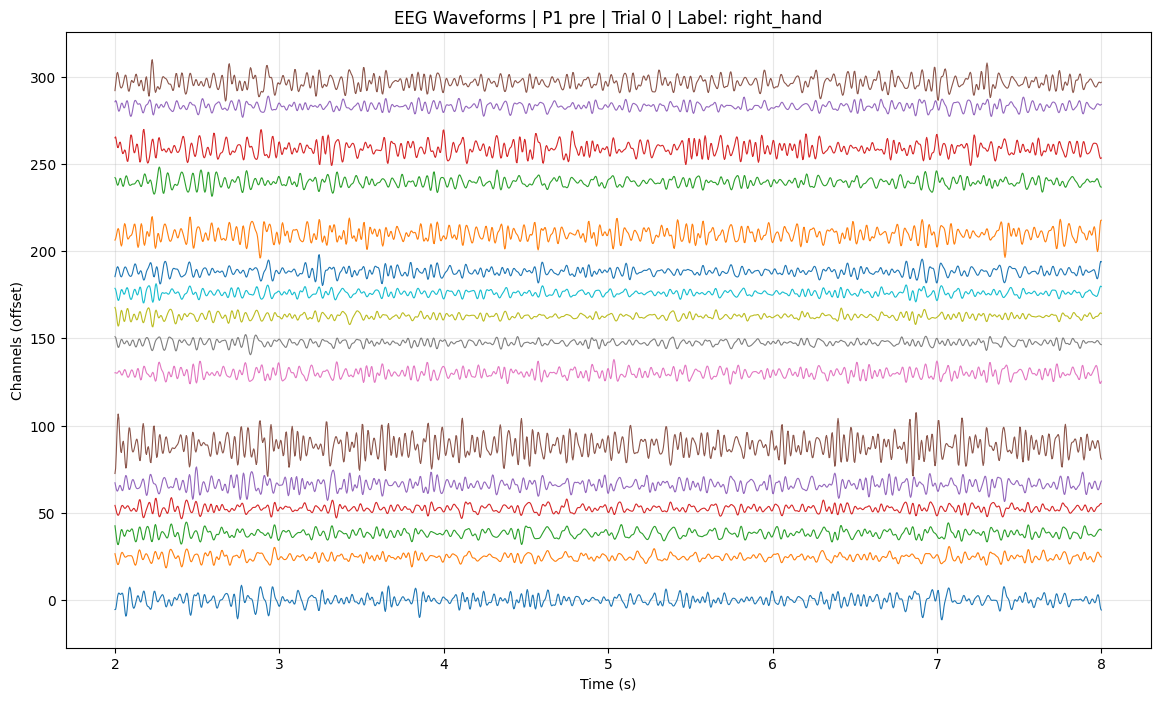

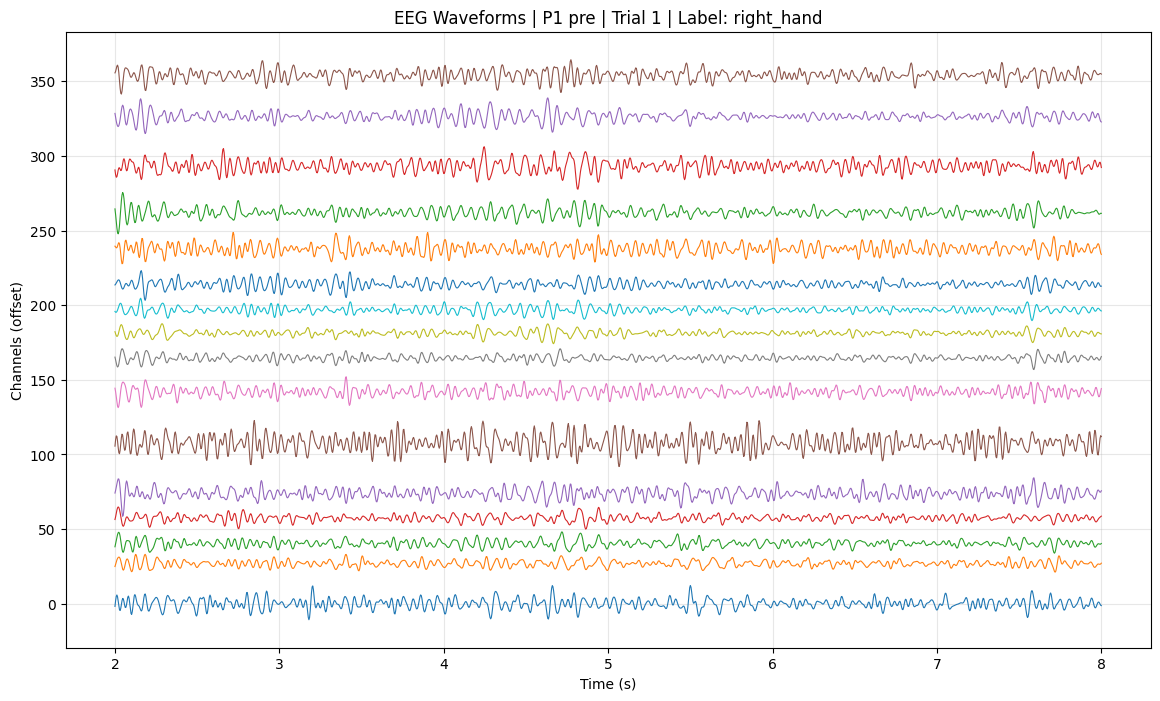

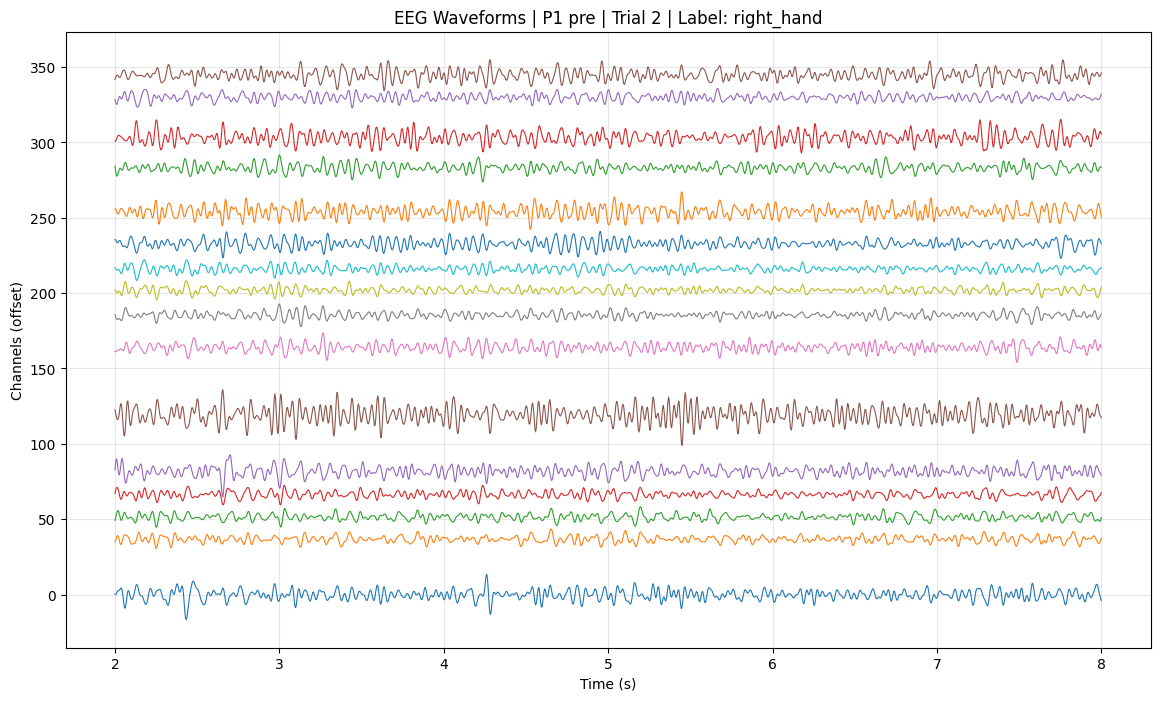

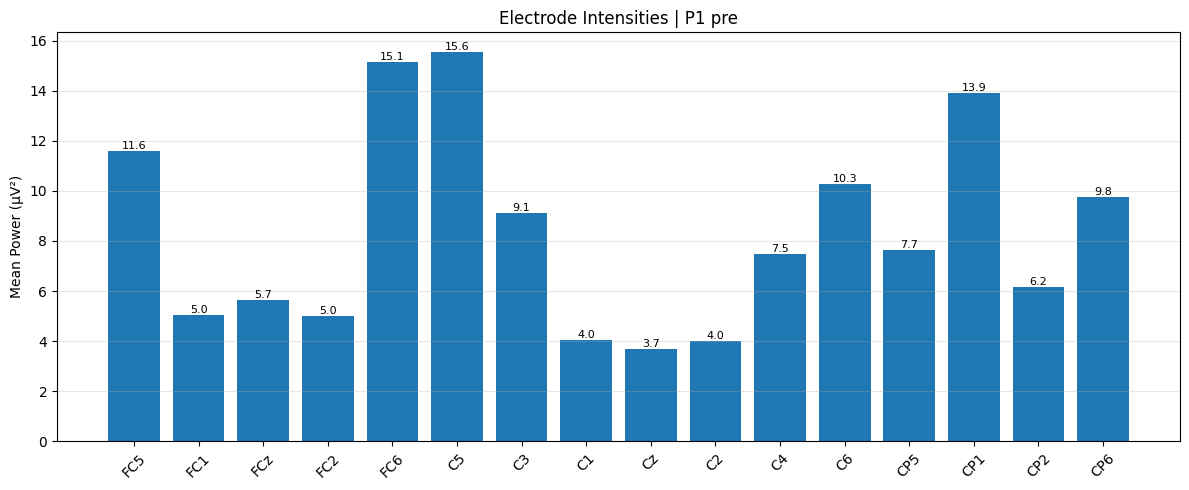

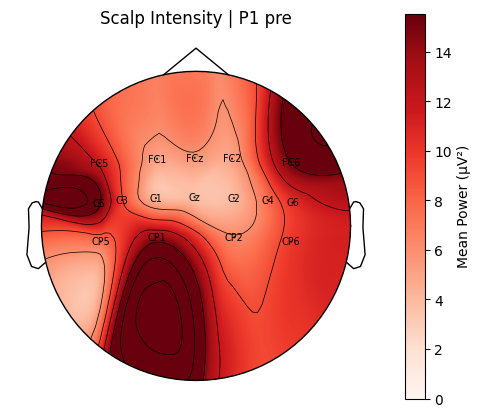

In [21]:
# ============================================================
# VISUALIZATION
# ============================================================

visualize_one_dataset(subject="P1", stage="pre")




FB + PCA + LDA | Subject: P1 | Stage: PRE
Sampling rate : 256 Hz
Filter banks  : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape : (80, 5, 16, 1537)  (trials x bands x channels x time)
X_test  shape : (80, 5, 16, 1537)
Train labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 36.25%
CV Accuracy       : 48.75% ± 12.75%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.32      0.25      0.28        40
  right_hand       0.3

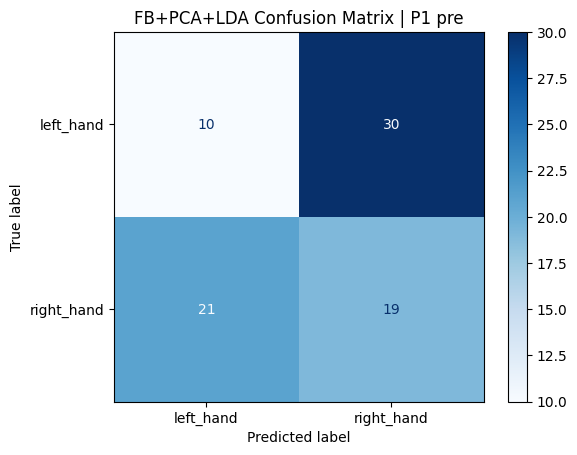


FB + PCA + LDA | Subject: P1 | Stage: POST
Sampling rate : 256 Hz
Filter banks  : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape : (79, 5, 16, 1537)  (trials x bands x channels x time)
X_test  shape : (80, 5, 16, 1537)
Train labels  : {np.int64(1): np.int64(39), np.int64(2): np.int64(40)}
Test  labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 55.00%
CV Accuracy       : 54.33% ± 5.51%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        39
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.56      0.45      0.50        40
  right_hand       0.5

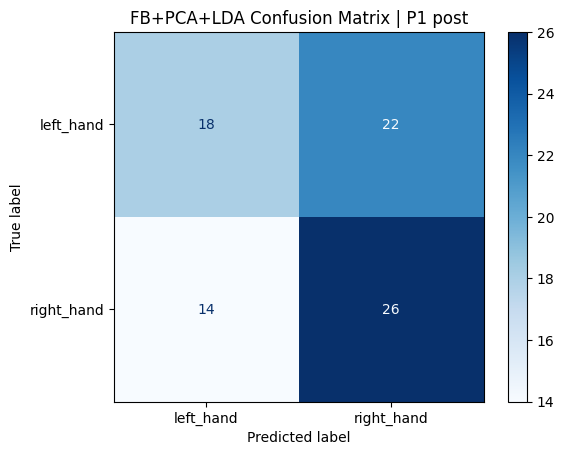


FB + PCA + LDA | Subject: P2 | Stage: PRE
Sampling rate : 256 Hz
Filter banks  : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape : (80, 5, 16, 1537)  (trials x bands x channels x time)
X_test  shape : (80, 5, 16, 1537)
Train labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 56.25%
CV Accuracy       : 43.75% ± 8.84%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.56      0.62      0.59        40
  right_hand       0.57

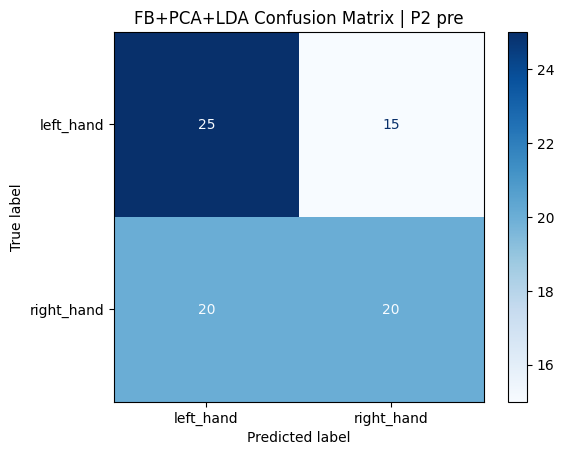


FB + PCA + LDA | Subject: P2 | Stage: POST
Sampling rate : 256 Hz
Filter banks  : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape : (80, 5, 16, 1537)  (trials x bands x channels x time)
X_test  shape : (80, 5, 16, 1537)
Train labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 42.50%
CV Accuracy       : 58.75% ± 14.58%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.41      0.35      0.38        40
  right_hand       0.

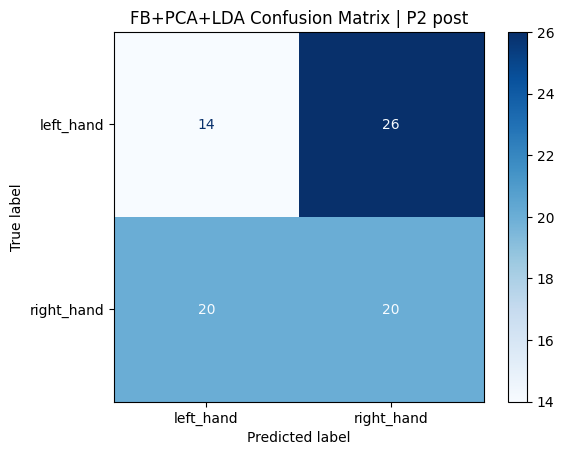


FB + PCA + LDA | Subject: P3 | Stage: PRE
Sampling rate : 256 Hz
Filter banks  : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape : (79, 5, 16, 1537)  (trials x bands x channels x time)
X_test  shape : (79, 5, 16, 1537)
Train labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(39)}
Test  labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(39)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 51.90%
CV Accuracy       : 47.00% ± 8.57%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        39

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.52      0.57      0.55        40
  right_hand       0.51

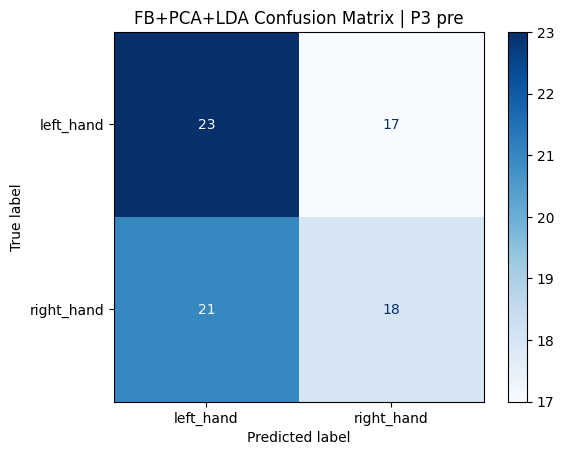


FB + PCA + LDA | Subject: P3 | Stage: POST
Sampling rate : 256 Hz
Filter banks  : [(8, 12), (12, 16), (16, 20), (20, 24), (24, 30)]
X_train shape : (80, 5, 16, 1537)  (trials x bands x channels x time)
X_test  shape : (80, 5, 16, 1537)
Train labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}
Test  labels  : {np.int64(1): np.int64(40), np.int64(2): np.int64(40)}

Accuracies
Training Accuracy : 100.00%
Test Accuracy     : 60.00%
CV Accuracy       : 52.50% ± 6.37%

Classification Report - TRAIN
              precision    recall  f1-score   support

   left_hand       1.00      1.00      1.00        40
  right_hand       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


Classification Report - TEST
              precision    recall  f1-score   support

   left_hand       0.60      0.60      0.60        40
  right_hand       0.6

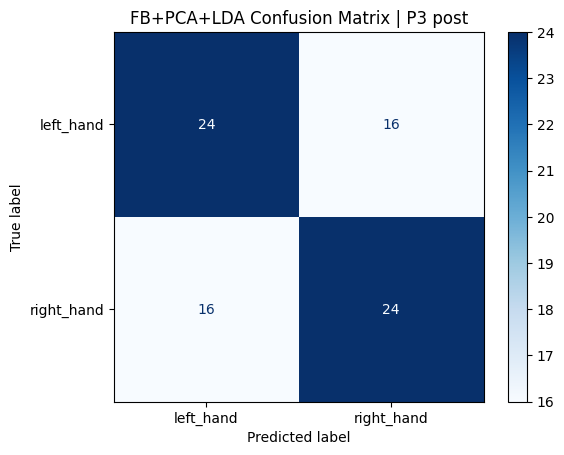

In [22]:
# ============================================================
# RUN ALL SUBJECTS AND STAGES
# ============================================================

results = []

for subject in SUBJECTS:
    for stage in STAGES:
        result = run_one_pair(subject, stage)
        results.append(result)



In [23]:
# ============================================================
# SUMMARY
# ============================================================

print("\n\nFILTER-BANK PCA + LDA SUMMARY")
print("=" * 80)

for r in results:
    print(
        f"{r['subject']} {r['stage']:>4} | "
        f"Train: {r['train_acc']*100:6.2f}% | "
        f"Test: {r['test_acc']*100:6.2f}% | "
        f"CV: {r['cv_acc']*100:6.2f}% ± {r['cv_std']*100:.2f}%"
    )





FILTER-BANK PCA + LDA SUMMARY
P1  pre | Train: 100.00% | Test:  36.25% | CV:  48.75% ± 12.75%
P1 post | Train: 100.00% | Test:  55.00% | CV:  54.33% ± 5.51%
P2  pre | Train: 100.00% | Test:  56.25% | CV:  43.75% ± 8.84%
P2 post | Train: 100.00% | Test:  42.50% | CV:  58.75% ± 14.58%
P3  pre | Train: 100.00% | Test:  51.90% | CV:  47.00% ± 8.57%
P3 post | Train: 100.00% | Test:  60.00% | CV:  52.50% ± 6.37%


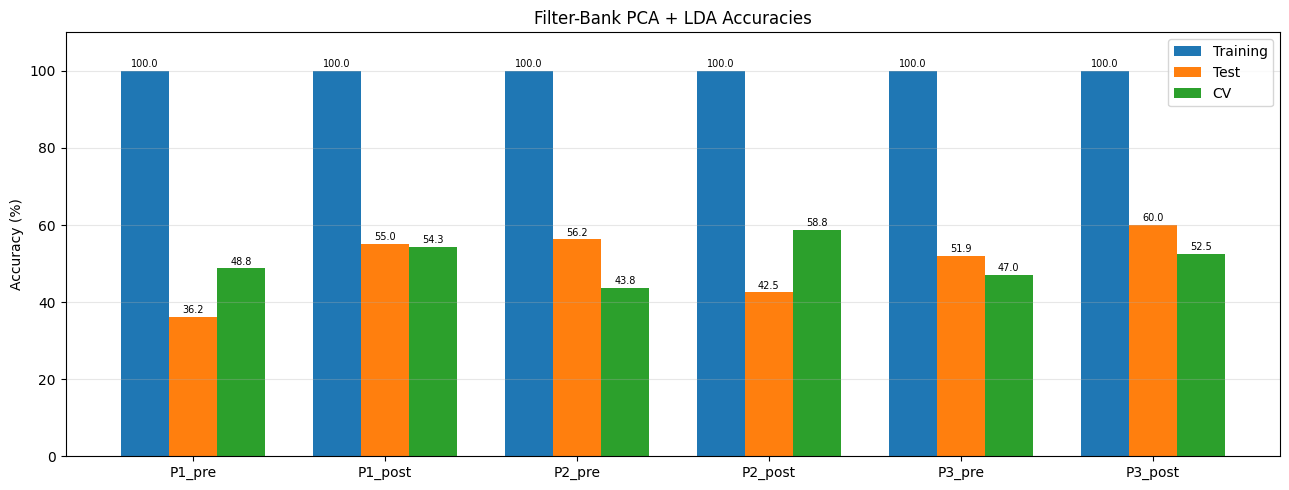

In [24]:
# ============================================================
# BAR GRAPH
# ============================================================

labels     = [f"{r['subject']}_{r['stage']}" for r in results]
train_accs = [r["train_acc"] * 100 for r in results]
test_accs  = [r["test_acc"]  * 100 for r in results]
cv_accs    = [r["cv_acc"]    * 100 for r in results]

x     = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(13, 5))
plt.bar(x - width, train_accs, width, label="Training")
plt.bar(x,         test_accs,  width, label="Test")
plt.bar(x + width, cv_accs,    width, label="CV")

plt.xticks(x, labels)
plt.ylabel("Accuracy (%)")
plt.title("Filter-Bank PCA + LDA Accuracies")
plt.ylim(0, 110)
plt.legend()
plt.grid(axis="y", alpha=0.3)

for i, (tr, te, cv) in enumerate(zip(train_accs, test_accs, cv_accs)):
    plt.text(x[i] - width, tr + 1, f"{tr:.1f}", ha="center", fontsize=7)
    plt.text(x[i],         te + 1, f"{te:.1f}", ha="center", fontsize=7)
    plt.text(x[i] + width, cv + 1, f"{cv:.1f}", ha="center", fontsize=7)

plt.tight_layout()
plt.show()